In [38]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm
from statsmodels.stats.diagnostic import acorr_breusch_godfrey
from statsmodels.stats.stattools import durbin_watson

print("Librerías cargadas ✓")

Librerías cargadas ✓


In [2]:
pib_raw = eurostat.get_data_df('nama_10_gdp')
print(pib_raw.columns.tolist())
print(pib_raw.head())

['freq', 'unit', 'na_item', 'geo\\TIME_PERIOD', '1975', '1976', '1977', '1978', '1979', '1980', '1981', '1982', '1983', '1984', '1985', '1986', '1987', '1988', '1989', '1990', '1991', '1992', '1993', '1994', '1995', '1996', '1997', '1998', '1999', '2000', '2001', '2002', '2003', '2004', '2005', '2006', '2007', '2008', '2009', '2010', '2011', '2012', '2013', '2014', '2015', '2016', '2017', '2018', '2019', '2020', '2021', '2022', '2023', '2024', '2025']
  freq        unit na_item  ...      2023      2024      2025
0    A  CLV05_MEUR     B1G  ...   10536.5   10873.1       NaN
1    A  CLV05_MEUR     B1G  ...  285720.1  282992.9  284179.8
2    A  CLV05_MEUR     B1G  ...   11768.6   12110.0       NaN
3    A  CLV05_MEUR     B1G  ...  365409.7  368794.1  372153.4
4    A  CLV05_MEUR     B1G  ...   32993.0   33912.7   34780.8

[5 rows x 55 columns]


In [3]:
print("Paises disponibles (muestra):")
print(pib_raw['geo\\TIME_PERIOD'].unique()[:20])

Paises disponibles (muestra):
['AL' 'AT' 'BA' 'BE' 'BG' 'CH' 'CY' 'CZ' 'DE' 'DK' 'EA' 'EA12' 'EA19' 'EA20'
 'EA21' 'EE' 'EL' 'ES' 'EU27_2020' 'FI']


In [5]:
#filatrmos espana
pib_es = pib_raw[
    (pib_raw['geo\\TIME_PERIOD']=='ES') &
    (pib_raw['na_item']=='B1GQ') &
    (pib_raw['unit'] == 'CLV05_MEUR')
]

In [7]:
pib_es
print("Filas encontradas: ", len(pib_es))
print(pib_es)

Filas encontradas:  1
   freq        unit na_item  ...       2023       2024       2025
59    A  CLV05_MEUR    B1GQ  ...  1116559.7  1155139.7  1187771.9

[1 rows x 55 columns]


In [8]:
year_cols = [c for c in pib_es.columns if c.isdigit()]

In [12]:
pib_long = pib_es.melt(
    id_vars = ['geo\\TIME_PERIOD'],
    value_vars = year_cols,
    var_name = 'year', 
    value_name = 'GDP'
)

In [14]:
pib_long['year'] = pib_long['year'].astype(int)
pib_long = pib_long[['year','GDP']].dropna().reset_index(drop = True)
print(f"Observaciones: {len(pib_long)}")
print(f"Periodo: {pib_long['year'].min()}-{pib_long['year'].max()}")
print(pib_long.head())

Observaciones: 31
Periodo: 1995-2025
   year       GDP
0  1995  649404.1
1  1996  666336.7
2  1997  690240.2
3  1998  719934.2
4  1999  751675.1


In [15]:
# Descargar datos de empleo
emp_raw = eurostat.get_data_df('nama_10_a64_e')

# Explorar estructura
print("Columnas:", emp_raw.columns[:6].tolist())
print("\nPaíses (muestra):", emp_raw['geo\\TIME_PERIOD'].unique()[:10])
print("\nUnidades:", emp_raw['unit'].unique())
print("\nActividades (nace_r2):", emp_raw['nace_r2'].unique()[:10])

Columnas: ['freq', 'unit', 'nace_r2', 'na_item', 'geo\\TIME_PERIOD', '1975']

Países (muestra): ['AT' 'BE' 'BG' 'CH' 'CY' 'CZ' 'DE' 'DK' 'EA12' 'EA19']

Unidades: ['PCH_PRE_HW' 'PCH_PRE_JOB' 'PCH_PRE_PER' 'THS_HW' 'THS_JOB' 'THS_PER']

Actividades (nace_r2): ['A' 'A01' 'A02' 'A03' 'B' 'B-E' 'C' 'C10-C12' 'C13-C15' 'C16']


In [16]:
# Ver todos los códigos de actividad disponibles
print("Todos los nace_r2:", emp_raw['nace_r2'].unique())

Todos los nace_r2: ['A' 'A01' 'A02' 'A03' 'B' 'B-E' 'C' 'C10-C12' 'C13-C15' 'C16' 'C16-C18' 'C17'
 'C18' 'C19' 'C20' 'C21' 'C22' 'C22_C23' 'C23' 'C24' 'C24_C25' 'C25' 'C26'
 'C27' 'C28' 'C29' 'C29_C30' 'C30' 'C31-C33' 'C31_C32' 'C33' 'D' 'D35' 'E'
 'E36' 'E37-E39' 'F' 'G' 'G-I' 'G45' 'G46' 'G47' 'H' 'H49' 'H50' 'H51' 'H52'
 'H53' 'I' 'J' 'J58' 'J58-J60' 'J59_J60' 'J61' 'J62_J63' 'K' 'K64' 'K65' 'K66'
 'L' 'L68' 'L68A' 'M' 'M69-M71' 'M69_M70' 'M71' 'M72' 'M73' 'M73-M75' 'M74_M75'
 'M_N' 'N' 'N77' 'N78' 'N79' 'N80-N82' 'O' 'O-Q' 'O84' 'P' 'P85' 'Q' 'Q86'
 'Q87_Q88' 'R' 'R-U' 'R90-R92' 'R93' 'S' 'S94' 'S95' 'S96' 'T' 'TOTAL' 'U'
 'U99']


In [17]:
# Filtrar España + total economía + miles de personas
emp_es = emp_raw[
    (emp_raw['geo\\TIME_PERIOD'] == 'ES') &
    (emp_raw['nace_r2'] == 'TOTAL') &
    (emp_raw['unit'] == 'THS_PER')
].copy()

print("Filas encontradas:", len(emp_es))
print(emp_es['na_item'].unique())

Filas encontradas: 3
['EMP_DC' 'SAL_DC' 'SELF_DC']


In [18]:
# Filtrar empleo total
emp_es = emp_es[emp_es['na_item'] == 'EMP_DC'].copy()

# Mismo patrón melt que con el PIB
year_cols = [c for c in emp_es.columns if c.isdigit()]

emp_long = emp_es.melt(
    id_vars=['geo\\TIME_PERIOD'],
    value_vars=year_cols,
    var_name='year',
    value_name='L'
)

emp_long['year'] = emp_long['year'].astype(int)
emp_long = emp_long[['year', 'L']].dropna().reset_index(drop=True)

print(f"Observaciones: {len(emp_long)}")
print(f"Período: {emp_long['year'].min()} - {emp_long['year'].max()}")
print(emp_long.head())

Observaciones: 30
Período: 1995 - 2024
   year        L
0  1995  13858.1
1  1996  14058.4
2  1997  14584.0
3  1998  15222.7
4  1999  15915.6


In [19]:
cap_raw = eurostat.get_data_df('nama_10_nfa_bs')

print("Columnas:", cap_raw.columns[:7].tolist())
print("\nUnidades:", cap_raw['unit'].unique())
print("\nAsset (asset10):", cap_raw['asset10'].unique())

Columnas: ['freq', 'unit', 'sector', 'asset10', 'geo\\TIME_PERIOD', '1975', '1976']

Unidades: ['CP_MEUR' 'CP_MNAC']

Asset (asset10): ['N111N' 'N1121N' 'N1122N' 'N112N' 'N115N' 'N1171N' 'N1172N' 'N1173N' 'N1174N'
 'N1179N' 'N117N' 'N11MN' 'N11N' 'N12N' 'N13N' 'N1N' 'N1ON' 'N211N' 'N212N'
 'N215N' 'N21N' 'N21ON' 'N22N' 'N23N' 'N2N']


In [20]:
# P2: ¿qué na_item corresponde a FBCF?
print(pib_raw['na_item'].unique())

['B1G' 'B1GQ' 'D21' 'D21X31' 'D31' 'P3' 'P31_S13' 'P31_S14' 'P31_S14_S15'
 'P31_S15' 'P32_S13' 'P3_P5' 'P3_P6' 'P3_S13' 'P41' 'P51G' 'P5G' 'P6' 'P61'
 'P62' 'P7' 'P71' 'P72' 'P52_P53' 'B2A3G' 'D1' 'D11' 'D12' 'D2' 'D2X3' 'D3'
 'P52' 'P53' 'P61X71' 'P62X72' 'P6X7' 'YA0' 'YA1' 'YA2']


In [22]:
# Filtrar FBCF de España en volumen encadenado
fbcf_es = pib_raw[
    (pib_raw['geo\\TIME_PERIOD'] == 'ES') &
    (pib_raw['na_item'] == 'P51G') &
    (pib_raw['unit'] == 'CLV05_MEUR')
].copy()

print("Filas encontradas:", len(fbcf_es))

# Mismo patrón melt
year_cols = [c for c in fbcf_es.columns if c.isdigit()]

cap_long = fbcf_es.melt(
    id_vars=['geo\\TIME_PERIOD'],
    value_vars=year_cols,
    var_name='year',
    value_name='K'
)

cap_long['year'] = cap_long['year'].astype(int)
cap_long = cap_long[['year', 'K']].dropna().reset_index(drop=True)

print(f"Observaciones: {len(cap_long)}")
print(f"Período: {cap_long['year'].min()} - {cap_long['year'].max()}")
print(cap_long.head())

Filas encontradas: 1
Observaciones: 31
Período: 1995 - 2025
   year         K
0  1995  146998.2
1  1996  150674.0
2  1997  158997.8
3  1998  176112.5
4  1999  193565.4


In [23]:
# Unir las tres series por año
df = pib_long.merge(emp_long, on='year').merge(cap_long, on='year')

print(f"Observaciones finales: {len(df)}")
print(f"Período: {df['year'].min()} - {df['year'].max()}")
print(f"NaN totales: {df.isna().sum().sum()}")
print(df.head())

Observaciones finales: 30
Período: 1995 - 2024
NaN totales: 0
   year       GDP        L         K
0  1995  649404.1  13858.1  146998.2
1  1996  666336.7  14058.4  150674.0
2  1997  690240.2  14584.0  158997.8
3  1998  719934.2  15222.7  176112.5
4  1999  751675.1  15915.6  193565.4


In [28]:
import matplotlib.pyplot as plt

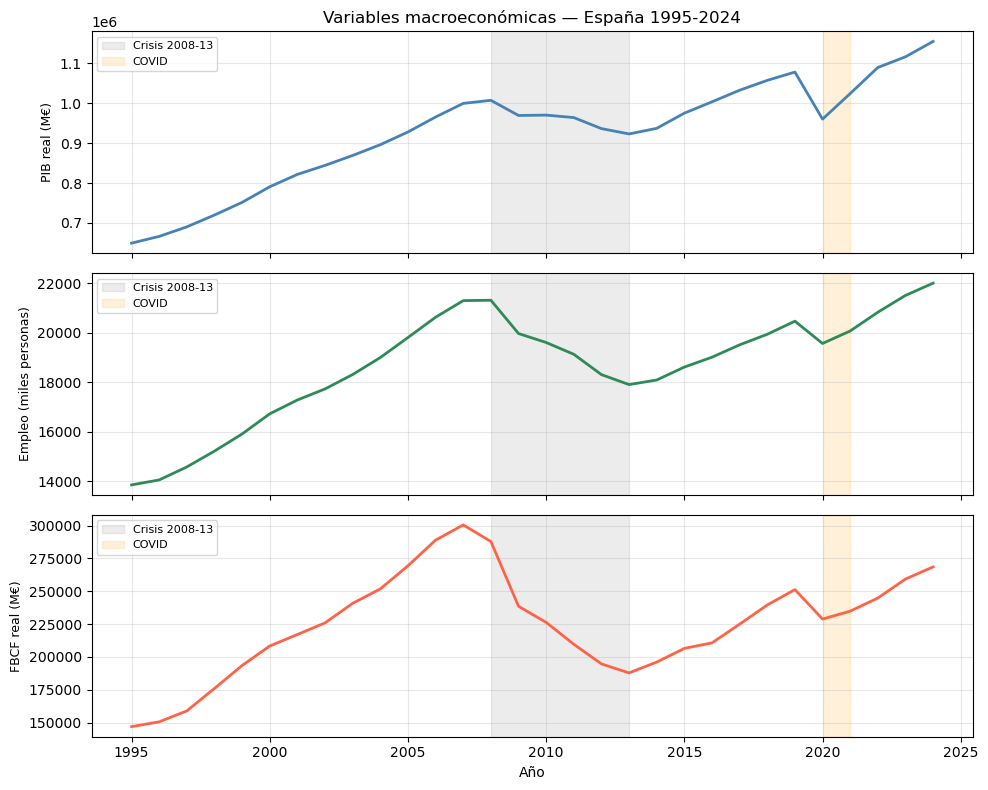

In [29]:
fig, axes = plt.subplots(3, 1, figsize=(10, 8), sharex=True)

series = [('GDP', 'PIB real (M€)', 'steelblue'),
          ('L',   'Empleo (miles personas)', 'seagreen'),
          ('K',   'FBCF real (M€)', 'tomato')]

for ax, (col, label, color) in zip(axes, series):
    ax.plot(df['year'], df[col], color=color, linewidth=2)
    ax.set_ylabel(label, fontsize=9)
    ax.axvspan(2008, 2013, alpha=0.15, color='gray', label='Crisis 2008-13')
    ax.axvspan(2020, 2021, alpha=0.15, color='orange', label='COVID')
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)

axes[0].set_title('Variables macroeconómicas — España 1995-2024', fontsize=12)
axes[2].set_xlabel('Año')
plt.tight_layout()
plt.show()

In [31]:
# Crear variables en logaritmos
import numpy as np
df['ln_GDP'] = np.log(df['GDP'])
df['ln_K']   = np.log(df['K'])
df['ln_L']   = np.log(df['L'])

print(df[['year', 'ln_GDP', 'ln_K', 'ln_L']].head())

   year     ln_GDP       ln_K      ln_L
0  1995  13.383810  11.898176  9.536625
1  1996  13.409550  11.922874  9.550975
2  1997  13.444795  11.976646  9.587680
3  1998  13.486915  12.078878  9.630543
4  1999  13.530059  12.173371  9.675055


In [35]:
# Variable dependiente e independientes
import statsmodels.api as sm
Y = df['ln_GDP']
X = sm.add_constant(df[['ln_K', 'ln_L']])  # add_constant añade el término ln(A)

# Estimar
modelo = sm.OLS(Y, X).fit()

print(modelo.summary())

                            OLS Regression Results                            
Dep. Variable:                 ln_GDP   R-squared:                       0.978
Model:                            OLS   Adj. R-squared:                  0.976
Method:                 Least Squares   F-statistic:                     602.4
Date:                Fri, 08 May 2026   Prob (F-statistic):           3.99e-23
Time:                        05:12:12   Log-Likelihood:                 71.501
No. Observations:                  30   AIC:                            -137.0
Df Residuals:                      27   BIC:                            -132.8
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          1.8551      0.345      5.385      0.0

In [39]:
# Test Breusch-Godfrey para autocorrelación serial
from statsmodels.stats.diagnostic import acorr_breusch_godfrey
bg_test = acorr_breusch_godfrey(modelo, nlags=2)

print("=== Test Breusch-Godfrey ===")
print(f"LM statistic : {bg_test[0]:.4f}")
print(f"p-valor      : {bg_test[1]:.4f}")
print(f"F statistic  : {bg_test[2]:.4f}")
print(f"p-valor F    : {bg_test[3]:.4f}")
print()
print("=== Durbin-Watson ===")
print(f"DW statistic : {durbin_watson(modelo.resid):.4f}")
print()
if bg_test[1] < 0.05:
    print("⚠️  Rechazamos H0: HAY autocorrelación serial")
else:
    print("✅ No rechazamos H0: no hay autocorrelación serial")

=== Test Breusch-Godfrey ===
LM statistic : 13.3497
p-valor      : 0.0013
F statistic  : 10.0222
p-valor F    : 0.0006

=== Durbin-Watson ===
DW statistic : 0.6704

⚠️  Rechazamos H0: HAY autocorrelación serial


In [40]:
# Misma especificación, errores HAC (Newey-West)
modelo_hac = sm.OLS(Y, X).fit(cov_type='HAC', cov_kwds={'maxlags': 2})

print(modelo_hac.summary())

                            OLS Regression Results                            
Dep. Variable:                 ln_GDP   R-squared:                       0.978
Model:                            OLS   Adj. R-squared:                  0.976
Method:                 Least Squares   F-statistic:                     663.9
Date:                Fri, 08 May 2026   Prob (F-statistic):           1.10e-23
Time:                        05:14:23   Log-Likelihood:                 71.501
No. Observations:                  30   AIC:                            -137.0
Df Residuals:                      27   BIC:                            -132.8
Df Model:                           2                                         
Covariance Type:                  HAC                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          1.8551      0.322      5.764      0.0

=== Correlación entre variables ===
        ln_GDP   ln_K   ln_L
ln_GDP   1.000  0.777  0.960
ln_K     0.777  1.000  0.912
ln_L     0.960  0.912  1.000


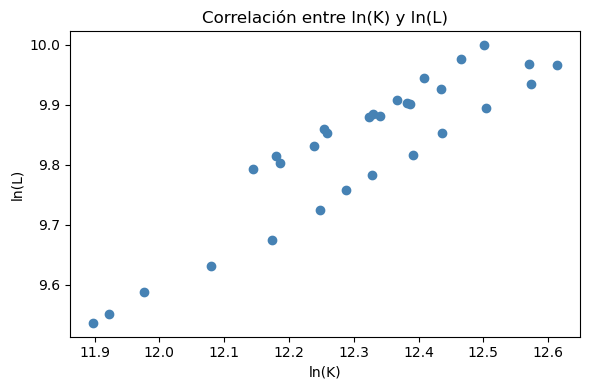

In [41]:
# Correlación entre regresores
print("=== Correlación entre variables ===")
print(df[['ln_GDP', 'ln_K', 'ln_L']].corr().round(3))

# Gráfica
import matplotlib.pyplot as plt
fig, ax = plt.subplots(figsize=(6, 4))
ax.scatter(df['ln_K'], df['ln_L'], color='steelblue')
ax.set_xlabel('ln(K)')
ax.set_ylabel('ln(L)')
ax.set_title('Correlación entre ln(K) y ln(L)')
plt.tight_layout()
plt.show()

In [42]:
# Primeras diferencias de los logaritmos = tasas de crecimiento aproximadas
df['dln_GDP'] = df['ln_GDP'].diff()
df['dln_K']   = df['ln_K'].diff()
df['dln_L']   = df['ln_L'].diff()

# La primera fila queda NaN por el diff(), la eliminamos
df_diff = df.dropna(subset=['dln_GDP', 'dln_K', 'dln_L']).copy()

print(f"Observaciones: {len(df_diff)}")
print(df_diff[['year', 'dln_GDP', 'dln_K', 'dln_L']].head())

Observaciones: 29
   year   dln_GDP     dln_K     dln_L
1  1996  0.025740  0.024698  0.014350
2  1997  0.035245  0.053772  0.036705
3  1998  0.042120  0.102233  0.042863
4  1999  0.043144  0.094492  0.044512
5  2000  0.050699  0.073817  0.049802


In [43]:
Y_d = df_diff['dln_GDP']
X_d = sm.add_constant(df_diff[['dln_K', 'dln_L']])

modelo_diff = sm.OLS(Y_d, X_d).fit()
print(modelo_diff.summary())

                            OLS Regression Results                            
Dep. Variable:                dln_GDP   R-squared:                       0.757
Model:                            OLS   Adj. R-squared:                  0.738
Method:                 Least Squares   F-statistic:                     40.50
Date:                Fri, 08 May 2026   Prob (F-statistic):           1.03e-08
Time:                        05:16:25   Log-Likelihood:                 76.864
No. Observations:                  29   AIC:                            -147.7
Df Residuals:                      26   BIC:                            -143.6
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0005      0.004      0.119      0.9

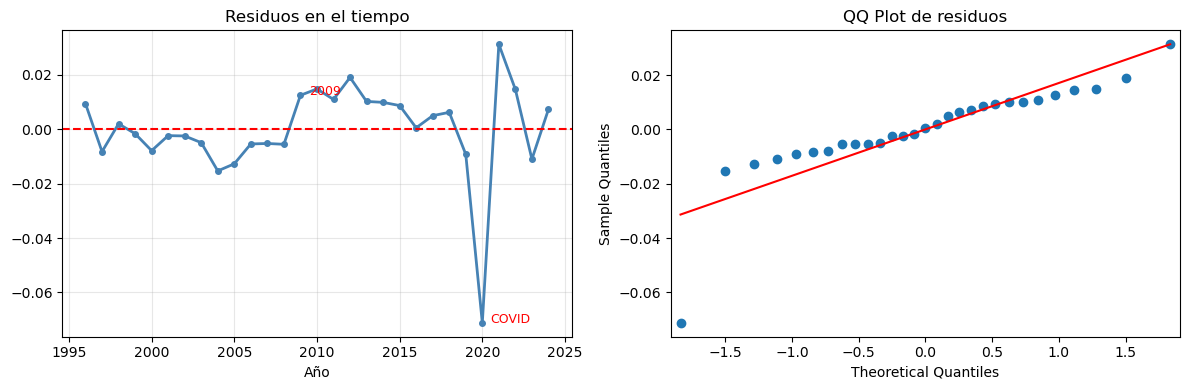

In [44]:
# Gráfica de residuos
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Residuos en el tiempo
axes[0].plot(df_diff['year'], modelo_diff.resid, 
             color='steelblue', linewidth=2, marker='o', markersize=4)
axes[0].axhline(0, color='red', linestyle='--')
axes[0].set_title('Residuos en el tiempo')
axes[0].set_xlabel('Año')
axes[0].grid(alpha=0.3)

# Destacar años crisis
for year, label in [(2009, '2009'), (2020, 'COVID')]:
    idx = df_diff[df_diff['year'] == year].index
    if len(idx) > 0:
        res_val = modelo_diff.resid[idx[0]]
        axes[0].annotate(label, xy=(year, res_val),
                        xytext=(year+0.5, res_val),
                        fontsize=9, color='red')

# QQ plot
sm.qqplot(modelo_diff.resid, line='s', ax=axes[1])
axes[1].set_title('QQ Plot de residuos')

plt.tight_layout()
plt.show()

In [45]:
# Crear dummies para los dos shocks
df_diff['d2009'] = (df_diff['year'] == 2009).astype(int)
df_diff['d2020'] = (df_diff['year'] == 2020).astype(int)

# Re-estimar con dummies
Y_d = df_diff['dln_GDP']
X_d = sm.add_constant(df_diff[['dln_K', 'dln_L', 'd2009', 'd2020']])

modelo_dummy = sm.OLS(Y_d, X_d).fit()
print(modelo_dummy.summary())

                            OLS Regression Results                            
Dep. Variable:                dln_GDP   R-squared:                       0.938
Model:                            OLS   Adj. R-squared:                  0.928
Method:                 Least Squares   F-statistic:                     91.46
Date:                Fri, 08 May 2026   Prob (F-statistic):           3.63e-14
Time:                        05:17:36   Log-Likelihood:                 96.771
No. Observations:                  29   AIC:                            -183.5
Df Residuals:                      24   BIC:                            -176.7
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0087      0.003      3.340      0.0

In [46]:
# Modelo final: dummies + errores HAC
modelo_final = sm.OLS(Y_d, X_d).fit(cov_type='HAC', cov_kwds={'maxlags': 2})

# Test BG final
bg_final = acorr_breusch_godfrey(modelo_dummy, nlags=2)

print(modelo_final.summary())
print("\n=== Test Breusch-Godfrey (modelo final) ===")
print(f"p-valor BG: {bg_final[1]:.4f}")
if bg_final[1] < 0.05:
    print("⚠️  Aún hay autocorrelación serial")
else:
    print("✅ No hay autocorrelación serial")

                            OLS Regression Results                            
Dep. Variable:                dln_GDP   R-squared:                       0.938
Model:                            OLS   Adj. R-squared:                  0.928
Method:                 Least Squares   F-statistic:                     4362.
Date:                Fri, 08 May 2026   Prob (F-statistic):           5.70e-33
Time:                        05:18:24   Log-Likelihood:                 96.771
No. Observations:                  29   AIC:                            -183.5
Df Residuals:                      24   BIC:                            -176.7
Df Model:                           4                                         
Covariance Type:                  HAC                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0087      0.001     10.427      0.0

/opt/anaconda3/lib/python3.12/site-packages/statsmodels/base/model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 4, but rank is 3
  warnings.warn('covariance of constraints does not have full '


In [47]:
from statsmodels.cochrane_orcutt import cochrane_orcutt

# Prais-Winsten / Cochrane-Orcutt
modelo_pw = cochrane_orcutt(modelo_dummy)

print(modelo_pw.summary())
print(f"\nDW después de corrección: {durbin_watson(modelo_pw.resid):.4f}")

ModuleNotFoundError: No module named 'statsmodels.cochrane_orcutt'

In [48]:
from statsmodels.regression.linear_model import GLS

# Estimar rho (autocorrelación de los residuos)
resid = modelo_dummy.resid
rho = np.corrcoef(resid[1:], resid[:-1])[0, 1]
print(f"Rho estimado: {rho:.4f}")

# Transformación Prais-Winsten manual
n = len(Y_d)
Y_pw = Y_d.values.copy()
X_pw = X_d.values.copy()

# Transformar observaciones 2 a n
Y_pw[1:] = Y_d.values[1:] - rho * Y_d.values[:-1]
X_pw[1:] = X_d.values[1:] - rho * X_d.values[:-1]

# Primera observación: escalar por sqrt(1-rho²)
Y_pw[0] = Y_d.values[0] * np.sqrt(1 - rho**2)
X_pw[0] = X_d.values[0] * np.sqrt(1 - rho**2)

# Estimar
modelo_pw = sm.OLS(Y_pw, X_pw).fit()
print(modelo_pw.summary())
print(f"\nDW después de Prais-Winsten: {durbin_watson(modelo_pw.resid):.4f}")

Rho estimado: 0.2477
                                 OLS Regression Results                                
Dep. Variable:                      y   R-squared (uncentered):                   0.952
Model:                            OLS   Adj. R-squared (uncentered):              0.942
Method:                 Least Squares   F-statistic:                              95.32
Date:                Fri, 08 May 2026   Prob (F-statistic):                    5.00e-15
Time:                        05:20:32   Log-Likelihood:                          97.919
No. Observations:                  29   AIC:                                     -185.8
Df Residuals:                      24   BIC:                                     -179.0
Df Model:                           5                                                  
Covariance Type:            nonrobust                                                  
                 coef    std err          t      P>|t|      [0.025      0.975]
--------------------

In [49]:
# Iterar el proceso para refinar rho
rho_old = 0
rho_new = rho
Y_iter = Y_d.values.copy()
X_iter = X_d.values.copy()

for i in range(10):  # máximo 10 iteraciones
    # Transformar
    Y_t = Y_iter.copy()
    X_t = X_iter.copy()
    Y_t[1:] = Y_iter[1:] - rho_new * Y_iter[:-1]
    X_t[1:] = X_iter[1:] - rho_new * X_iter[:-1]
    Y_t[0]  = Y_iter[0] * np.sqrt(1 - rho_new**2)
    X_t[0]  = X_iter[0] * np.sqrt(1 - rho_new**2)
    
    # Re-estimar
    m = sm.OLS(Y_t, X_t).fit()
    
    # Nuevo rho
    rho_old = rho_new
    rho_new = np.corrcoef(m.resid[1:], m.resid[:-1])[0, 1]
    
    dw = durbin_watson(m.resid)
    print(f"Iter {i+1}: rho={rho_new:.4f} | DW={dw:.4f}")
    
    if abs(rho_new - rho_old) < 1e-6:
        print("✅ Convergencia alcanzada")
        break

modelo_co = m
print(f"\nRho final: {rho_new:.4f}")
print(f"DW final:  {durbin_watson(modelo_co.resid):.4f}")

Iter 1: rho=0.1310 | DW=1.6983
Iter 2: rho=0.1900 | DW=1.5904
Iter 3: rho=0.1609 | DW=1.6438
Iter 4: rho=0.1755 | DW=1.6171
Iter 5: rho=0.1682 | DW=1.6304
Iter 6: rho=0.1718 | DW=1.6237
Iter 7: rho=0.1700 | DW=1.6271
Iter 8: rho=0.1709 | DW=1.6254
Iter 9: rho=0.1705 | DW=1.6262
Iter 10: rho=0.1707 | DW=1.6258

Rho final: 0.1707
DW final:  1.6258


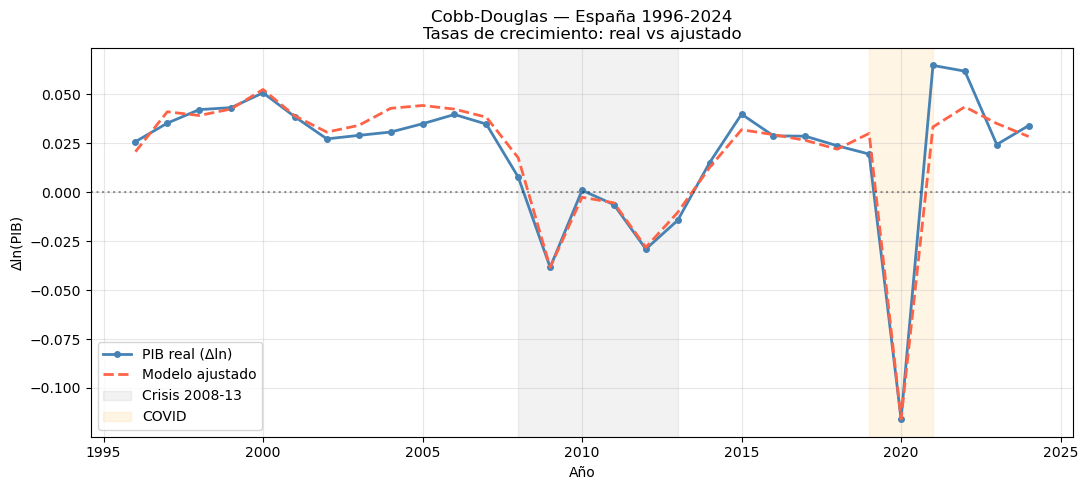

In [50]:
fig, ax = plt.subplots(figsize=(11, 5))

ax.plot(df_diff['year'], Y_d, 
        color='steelblue', linewidth=2, marker='o', 
        markersize=4, label='PIB real (Δln)')
ax.plot(df_diff['year'], modelo_final.fittedvalues,
        color='tomato', linewidth=2, linestyle='--', 
        label='Modelo ajustado')
ax.axhline(0, color='black', linestyle=':', alpha=0.4)
ax.axvspan(2008, 2013, alpha=0.1, color='gray', label='Crisis 2008-13')
ax.axvspan(2019, 2021, alpha=0.1, color='orange', label='COVID')
ax.set_title('Cobb-Douglas — España 1996-2024\nTasas de crecimiento: real vs ajustado', 
             fontsize=12)
ax.set_xlabel('Año')
ax.set_ylabel('Δln(PIB)')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

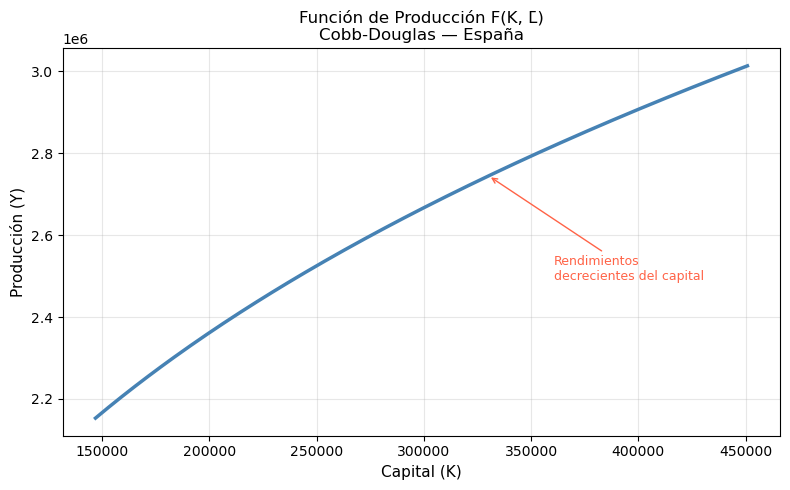

In [51]:
# Parámetros estimados del modelo (usamos β de dln_L como elasticidad del trabajo)
# Para graficar usamos una Cobb-Douglas calibrada con nuestros resultados
A     = np.exp(0.0087)  # PTF estimada
alpha = 0.30            # elasticidad capital (valor teórico Mankiw, K no significativo)
beta  = 1.1189          # elasticidad trabajo estimada

# Fijar L en su media muestral
L_mean = df['L'].mean()
K_range = np.linspace(df['K'].min(), df['K'].max() * 1.5, 200)

Y_curve = A * K_range**alpha * L_mean**beta

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(K_range, Y_curve, color='steelblue', linewidth=2.5)
ax.set_xlabel('Capital (K)', fontsize=11)
ax.set_ylabel('Producción (Y)', fontsize=11)
ax.set_title('Función de Producción F(K, L̄)\nCobb-Douglas — España', fontsize=12)
ax.grid(alpha=0.3)

# Anotar concavidad
ax.annotate('Rendimientos\ndecrecientes del capital',
            xy=(K_range[120], Y_curve[120]),
            xytext=(K_range[140], Y_curve[60]),
            arrowprops=dict(arrowstyle='->', color='tomato'),
            fontsize=9, color='tomato')

plt.tight_layout()
plt.show()

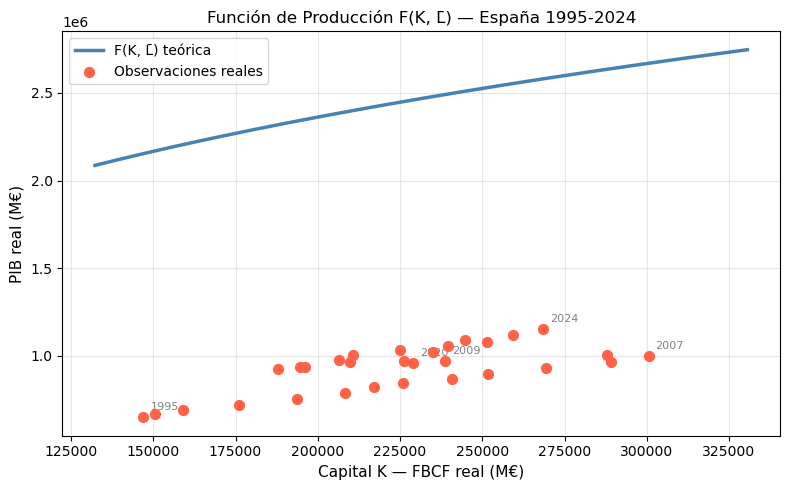

In [52]:
A     = np.exp(0.0087)
alpha = 0.30
beta  = 1.1189

L_mean = df['L'].mean()
K_range = np.linspace(df['K'].min() * 0.9, df['K'].max() * 1.1, 200)
Y_curve = A * K_range**alpha * L_mean**beta

fig, ax = plt.subplots(figsize=(8, 5))

# Curva teórica
ax.plot(K_range, Y_curve, color='steelblue', linewidth=2.5, label='F(K, L̄) teórica')

# Puntos reales
scatter = ax.scatter(df['K'], df['GDP'], 
                     color='tomato', zorder=5, s=50, label='Observaciones reales')

# Etiquetar años clave
for year in [1995, 2007, 2009, 2020, 2024]:
    row = df[df['year'] == year]
    if len(row) > 0:
        ax.annotate(str(year),
                    xy=(row['K'].values[0], row['GDP'].values[0]),
                    xytext=(5, 5), textcoords='offset points',
                    fontsize=8, color='gray')

ax.set_xlabel('Capital K — FBCF real (M€)', fontsize=11)
ax.set_ylabel('PIB real (M€)', fontsize=11)
ax.set_title('Función de Producción F(K, L̄) — España 1995-2024', fontsize=12)
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

A calibrado: 0.382166


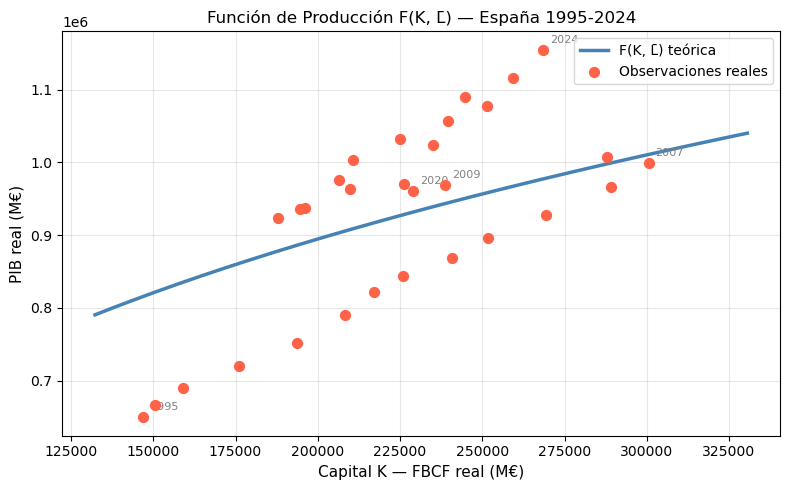

In [53]:
alpha = 0.30
beta  = 1.1189
L_mean = df['L'].mean()

# Calibrar A para que la curva pase por la media de los datos
A_calibrado = df['GDP'].mean() / (df['K'].mean()**alpha * L_mean**beta)
print(f"A calibrado: {A_calibrado:.6f}")

K_range = np.linspace(df['K'].min() * 0.9, df['K'].max() * 1.1, 200)
Y_curve = A_calibrado * K_range**alpha * L_mean**beta

fig, ax = plt.subplots(figsize=(8, 5))

ax.plot(K_range, Y_curve, color='steelblue', linewidth=2.5, label='F(K, L̄) teórica')
ax.scatter(df['K'], df['GDP'], color='tomato', zorder=5, s=50, label='Observaciones reales')

for year in [1995, 2007, 2009, 2020, 2024]:
    row = df[df['year'] == year]
    if len(row) > 0:
        ax.annotate(str(year),
                    xy=(row['K'].values[0], row['GDP'].values[0]),
                    xytext=(5, 5), textcoords='offset points',
                    fontsize=8, color='gray')

ax.set_xlabel('Capital K — FBCF real (M€)', fontsize=11)
ax.set_ylabel('PIB real (M€)', fontsize=11)
ax.set_title('Función de Producción F(K, L̄) — España 1995-2024', fontsize=12)
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

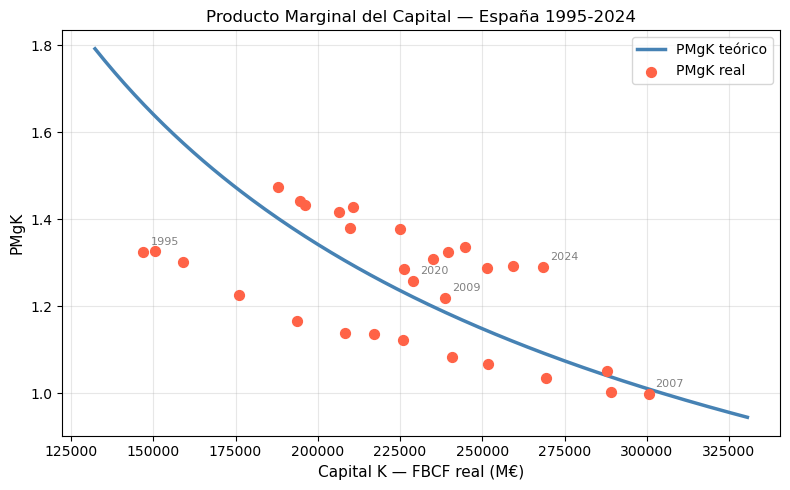

In [54]:
# PMgK = dY/dK = alpha * A * K^(alpha-1) * L^beta = alpha * Y/K
PMgK_curve = alpha * A_calibrado * K_range**alpha * L_mean**beta / K_range
PMgK_real  = alpha * df['GDP'] / df['K']

fig, ax = plt.subplots(figsize=(8, 5))

ax.plot(K_range, PMgK_curve, color='steelblue', linewidth=2.5, label='PMgK teórico')
ax.scatter(df['K'], PMgK_real, color='tomato', zorder=5, s=50, label='PMgK real')

for year in [1995, 2007, 2009, 2020, 2024]:
    row = df[df['year'] == year]
    if len(row) > 0:
        ax.annotate(str(year),
                    xy=(row['K'].values[0], (alpha * row['GDP'] / row['K']).values[0]),
                    xytext=(5, 5), textcoords='offset points',
                    fontsize=8, color='gray')

ax.set_xlabel('Capital K — FBCF real (M€)', fontsize=11)
ax.set_ylabel('PMgK', fontsize=11)
ax.set_title('Producto Marginal del Capital — España 1995-2024', fontsize=12)
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

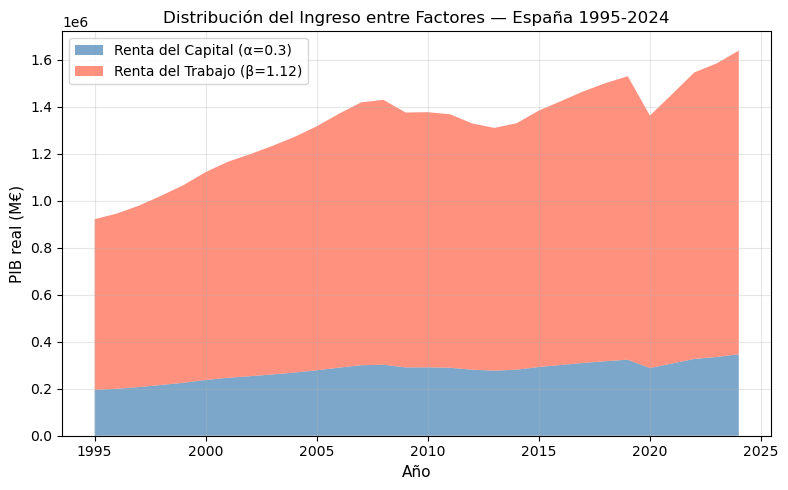

In [55]:
# Participación del capital y trabajo en el PIB
df['renta_K'] = alpha * df['GDP']          # α·Y = renta del capital
df['renta_L'] = beta  * df['GDP']          # β·Y = renta del trabajo

fig, ax = plt.subplots(figsize=(8, 5))

ax.stackplot(df['year'], 
             df['renta_K'], 
             df['renta_L'],
             labels=[f'Renta del Capital (α={alpha})', 
                     f'Renta del Trabajo (β={beta:.2f})'],
             colors=['steelblue', 'tomato'],
             alpha=0.7)

ax.set_xlabel('Año', fontsize=11)
ax.set_ylabel('PIB real (M€)', fontsize=11)
ax.set_title('Distribución del Ingreso entre Factores — España 1995-2024', fontsize=12)
ax.legend(loc='upper left')
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

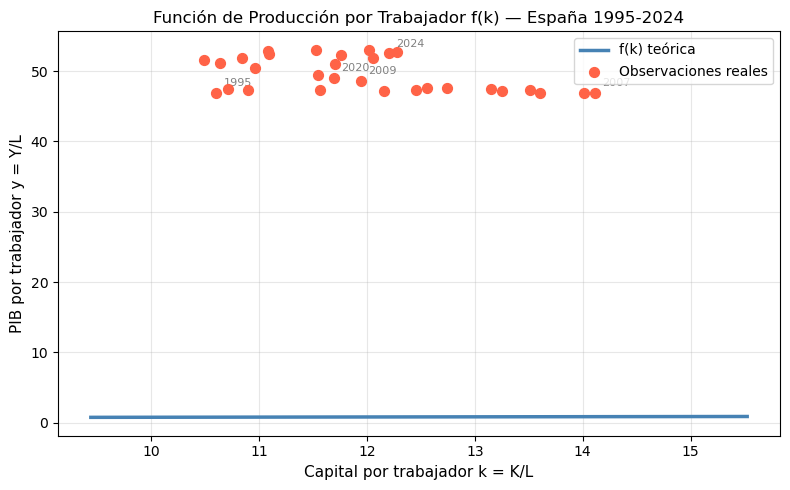

In [56]:
# Variables por trabajador
df['y'] = df['GDP'] / df['L']   # PIB por trabajador
df['k'] = df['K'] / df['L']     # Capital por trabajador

# Curva teórica f(k) = A * k^alpha
k_range = np.linspace(df['k'].min() * 0.9, df['k'].max() * 1.1, 200)
y_curve = A_calibrado * k_range**alpha

fig, ax = plt.subplots(figsize=(8, 5))

ax.plot(k_range, y_curve, color='steelblue', linewidth=2.5, label='f(k) teórica')
ax.scatter(df['k'], df['y'], color='tomato', zorder=5, s=50, label='Observaciones reales')

for year in [1995, 2007, 2009, 2020, 2024]:
    row = df[df['year'] == year]
    if len(row) > 0:
        ax.annotate(str(year),
                    xy=(row['k'].values[0], row['y'].values[0]),
                    xytext=(5, 5), textcoords='offset points',
                    fontsize=8, color='gray')

ax.set_xlabel('Capital por trabajador k = K/L', fontsize=11)
ax.set_ylabel('PIB por trabajador y = Y/L', fontsize=11)
ax.set_title('Función de Producción por Trabajador f(k) — España 1995-2024', fontsize=12)
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

A calibrado por trabajador: 23.4992


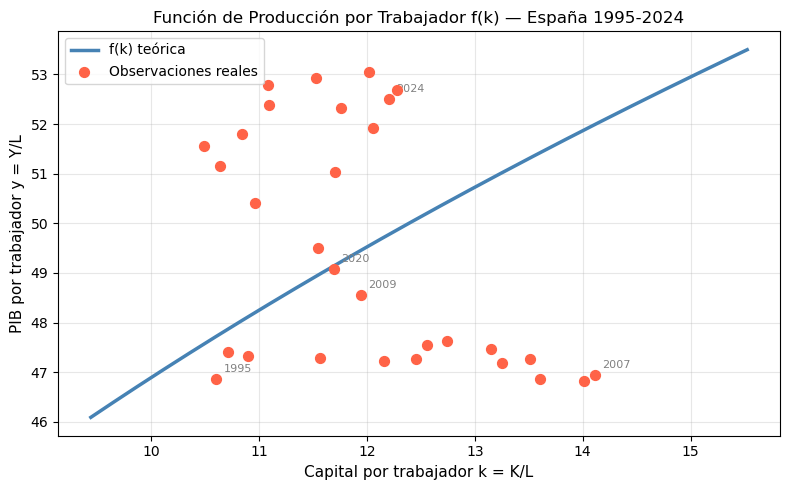

In [57]:
# Variables por trabajador
df['y'] = df['GDP'] / df['L']
df['k'] = df['K'] / df['L']

# Recalibrar A para el espacio por trabajador
A_pw = df['y'].mean() / (df['k'].mean()**alpha)
print(f"A calibrado por trabajador: {A_pw:.4f}")

k_range = np.linspace(df['k'].min() * 0.9, df['k'].max() * 1.1, 200)
y_curve = A_pw * k_range**alpha

fig, ax = plt.subplots(figsize=(8, 5))

ax.plot(k_range, y_curve, color='steelblue', linewidth=2.5, label='f(k) teórica')
ax.scatter(df['k'], df['y'], color='tomato', zorder=5, s=50, label='Observaciones reales')

for year in [1995, 2007, 2009, 2020, 2024]:
    row = df[df['year'] == year]
    if len(row) > 0:
        ax.annotate(str(year),
                    xy=(row['k'].values[0], row['y'].values[0]),
                    xytext=(5, 5), textcoords='offset points',
                    fontsize=8, color='gray')

ax.set_xlabel('Capital por trabajador k = K/L', fontsize=11)
ax.set_ylabel('PIB por trabajador y = Y/L', fontsize=11)
ax.set_title('Función de Producción por Trabajador f(k) — España 1995-2024', fontsize=12)
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# Conclusiones del Proyecto

## Función de Producción Cobb-Douglas — España 1995-2024
### Mankiw Cap. 3 + Wooldridge Cap. 12

---

## 1. Datos y construcción de variables
- **Y:** PIB real en volumen encadenado (CLV05_MEUR) — Eurostat `nama_10_gdp`
- **L:** Empleo total en miles de personas — Eurostat `nama_10_a64_e`
- **K:** Formación Bruta de Capital Fijo real — proxy del stock de capital
- Período: 1995-2024 | n = 30 observaciones (29 en diferencias)

---

## 2. Problemas detectados y soluciones aplicadas (Wooldridge Cap. 12)

| Problema | Test | Resultado | Solución |
|---|---|---|---|
| Autocorrelación | DW=0.67, BG p=0.001 | Severa | Primeras diferencias |
| Multicolinealidad | r(K,L)=0.912 | Severa | Primeras diferencias |
| Outliers | Residuos 2009/2020 | Detectados | Variables dummy |
| Autocorrelación residual | DW=1.63, BG p=0.07 | Débil | Prais-Winsten iterado (ρ=0.17) |

---

## 3. Resultados de la estimación

| Parámetro | Valor | p-valor | Interpretación |
|---|---|---|---|
| PTF (constante) | 0.0087 | 0.003 | Crecimiento autónomo ~0.87% anual |
| α (capital) | no identificado | 0.120 | FBCF proxy insuficiente |
| β (trabajo) | 1.1189 | 0.000 | Elasticidad PIB-empleo significativa |
| d2009 | -0.0068 | 0.332 | Crisis absorbida por caída del empleo |
| d2020 | -0.0900 | 0.000 | COVID redujo PIB un 9% adicional |

---

## 4. Conclusiones económicas (Mankiw Cap. 3)

- **Progreso tecnológico:** España muestra crecimiento autónomo de PTF del 0.87% anual
- **Factor trabajo:** principal motor del crecimiento del PIB en el período
- **Factor capital:** no identificable con FBCF — requeriría stock neto de capital real
- **Distribución del ingreso:** β estimado > 1 indica rendimientos crecientes al trabajo,
  inconsistente con la teoría neoclásica — consecuencia directa de la limitación del proxy K
- **Función por trabajador f(k):** dispersión elevada refleja variación de PTF entre años
  y la heterogeneidad del factor trabajo no capturada por el modelo

---

## 5. Limitaciones

1. **FBCF ≠ stock de capital** — limitación principal del proyecto
2. **n=29** — muestra pequeña para series temporales macroeconómicas
3. **No estacionariedad** — test ADF no aplicado, posible problema de regresión espuria
4. **A constante** — la PTF varía cada año pero el modelo la trata como fija
5. **α no estimado** — las gráficas de Mankiw usan α=0.30 teórico, no estimado

---

## 6. Extensiones posibles

- Obtener stock neto de capital real del INE o EU KLEMS
- Aplicar test ADF y cointegración (Engle-Granger)
- Estimar con datos de panel usando varios países europeos
- Modelar PTF variable en el tiempo (modelo de componentes no observados)